# Deep Learning Project 2: MLP Networks

# Part I — Synthetic Dataset Experiments

## Section 1 — Imports, Seeds, Dataset Generation

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
from sklearn.metrics import accuracy_score, f1_score
from tqdm import tqdm

# Fix seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Use CPU (project is designed for CPU)
device = torch.device('cpu')
print('Device:', device)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.5 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Reza\Python\Python312\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Reza\Python\Python312\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Reza\Python\Python312\Lib\site-packages\ipykernel\kernelapp.py", line 739, in start
    self.io_loop.start()
  File "C:\Reza\Python\Python312\Lib\site-pack

Device: cpu


In [2]:

def to_numpy(tensor):
    return tensor.detach().cpu().tolist()

# Monkey-patch برای راحتی
import torch
_orig_numpy = None
def tensor_to_numpy(self):
    return __import__('numpy').array(self.detach().cpu().tolist(), dtype='float32')
torch.Tensor.numpy = tensor_to_numpy


In [3]:
from sklearn.datasets import make_classification
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
from sklearn.metrics import accuracy_score, f1_score
from tqdm import tqdm

# DO NOT change this cell
X, y = make_classification(
    n_samples=3500,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_classes=2,
    n_clusters_per_class=2,
    class_sep=1,
    flip_y=0.15,
    random_state=42
)

print(f'Dataset shape: {X.shape}, Labels shape: {y.shape}')
print(f'Class distribution: {np.bincount(y)}')

Dataset shape: (3500, 2), Labels shape: (3500,)
Class distribution: [1763 1737]


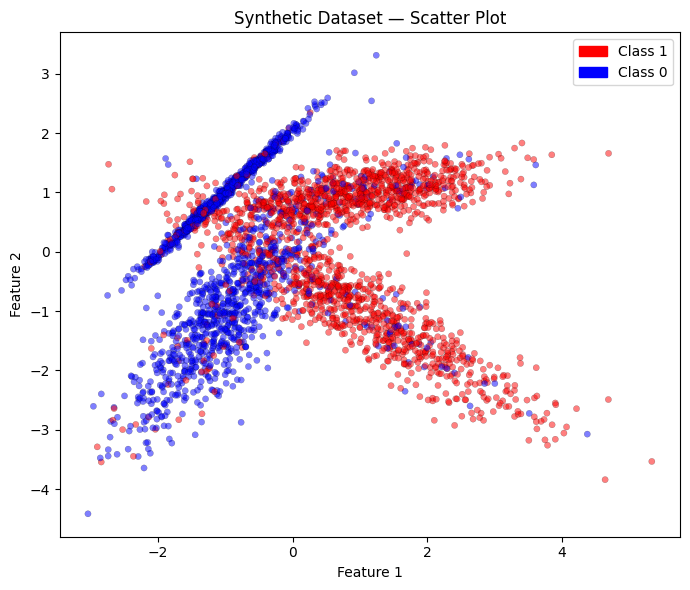

In [4]:
# Scatter plot of synthetic dataset
plt.figure(figsize=(7, 6))
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', alpha=0.5, edgecolors='k', linewidths=0.2, s=20)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Synthetic Dataset — Scatter Plot')
red_patch = mpatches.Patch(color='red', label='Class 1')
blue_patch = mpatches.Patch(color='blue', label='Class 0')
plt.legend(handles=[red_patch, blue_patch])
plt.tight_layout()
plt.show()

In [5]:
# Train/test split (80/20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize features (fit only on train)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert to tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32)

# DataLoaders
BATCH_SIZE = 128
train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset  = TensorDataset(X_test_t,  y_test_t)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader   = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Train size: {len(X_train)}, Test size: {len(X_test)}')

Train size: 2800, Test size: 700


---
## Section 2 — Effect of Depth & Width / Decision Boundaries

In [6]:
# ── Model factory ──────────────────────────────────────────────────────────────
def build_mlp(layer_sizes, activation=nn.ReLU):
    """Build a binary-classification MLP.
    layer_sizes: [input_dim, h1, h2, ..., 1]
    """
    layers = []
    for i in range(len(layer_sizes) - 1):
        layers.append(nn.Linear(layer_sizes[i], layer_sizes[i + 1]))
        if i < len(layer_sizes) - 2:          # no activation after last linear
            layers.append(activation())
    layers.append(nn.Sigmoid())
    return nn.Sequential(*layers)


# Five architectures  (naming: NeuronsxLayers)
architectures = {
    '1x2  Shallow & Narrow': [2, 2, 1],
    '1x16 Shallow & Wide':   [2, 16, 1],
    '4x4  Deep & Narrow':    [2, 4, 4, 4, 4, 1],
    '4x16 Deep & Wide':      [2, 16, 16, 16, 16, 1],
    '8x128 Deeper & Wider':  [2, 128, 128, 128, 128, 128, 128, 128, 128, 1],
}

EPOCHS = 100
LR     = 0.001


# ── Training function ──────────────────────────────────────────────────────────
def train_model(model, train_loader, test_loader, epochs=EPOCHS, lr=LR):
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses, val_losses = [], []

    for epoch in range(epochs):
        # ---- train ----
        model.train()
        running_loss = 0.0
        for Xb, yb in train_loader:
            optimizer.zero_grad()
            pred = model(Xb).view(-1)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * Xb.size(0)
        train_losses.append(running_loss / len(train_loader.dataset))

        # ---- evaluate ----
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for Xb, yb in test_loader:
                pred = model(Xb).view(-1)
                val_loss += criterion(pred, yb).item() * Xb.size(0)
        val_losses.append(val_loss / len(test_loader.dataset))

    return model, train_losses, val_losses


# ── Evaluate accuracy ──────────────────────────────────────────────────────────
def evaluate(model, X_t, y_np):
    model.eval()
    with torch.no_grad():
        probs = model(X_t).view(-1)
        preds = (probs >= 0.5).long().tolist()
    return accuracy_score(y_np, preds)


print('Architecture definitions ready.')

Architecture definitions ready.


In [7]:
torch.manual_seed(42)

results = {}  # {name: {'model', 'train_losses', 'val_losses', 'test_acc'}}

for name, sizes in architectures.items():
    print(f'Training: {name} ...')
    model = build_mlp(sizes)
    model, tr_l, va_l = train_model(model, train_loader, test_loader, epochs=EPOCHS, lr=LR)
    acc = evaluate(model, X_test_t, y_test)
    results[name] = {
        'model': model,
        'train_losses': tr_l,
        'val_losses': va_l,
        'test_acc': acc
    }
    print(f'  Final train loss: {tr_l[-1]:.4f} | val loss: {va_l[-1]:.4f} | test acc: {acc:.4f}')

print('\nAll models trained.')

Training: 1x2  Shallow & Narrow ...
  Final train loss: 0.4178 | val loss: 0.4777 | test acc: 0.8171
Training: 1x16 Shallow & Wide ...
  Final train loss: 0.3931 | val loss: 0.4506 | test acc: 0.8257
Training: 4x4  Deep & Narrow ...
  Final train loss: 0.3653 | val loss: 0.4127 | test acc: 0.8414
Training: 4x16 Deep & Wide ...
  Final train loss: 0.3301 | val loss: 0.3835 | test acc: 0.8671
Training: 8x128 Deeper & Wider ...
  Final train loss: 0.3213 | val loss: 0.3786 | test acc: 0.8700

All models trained.


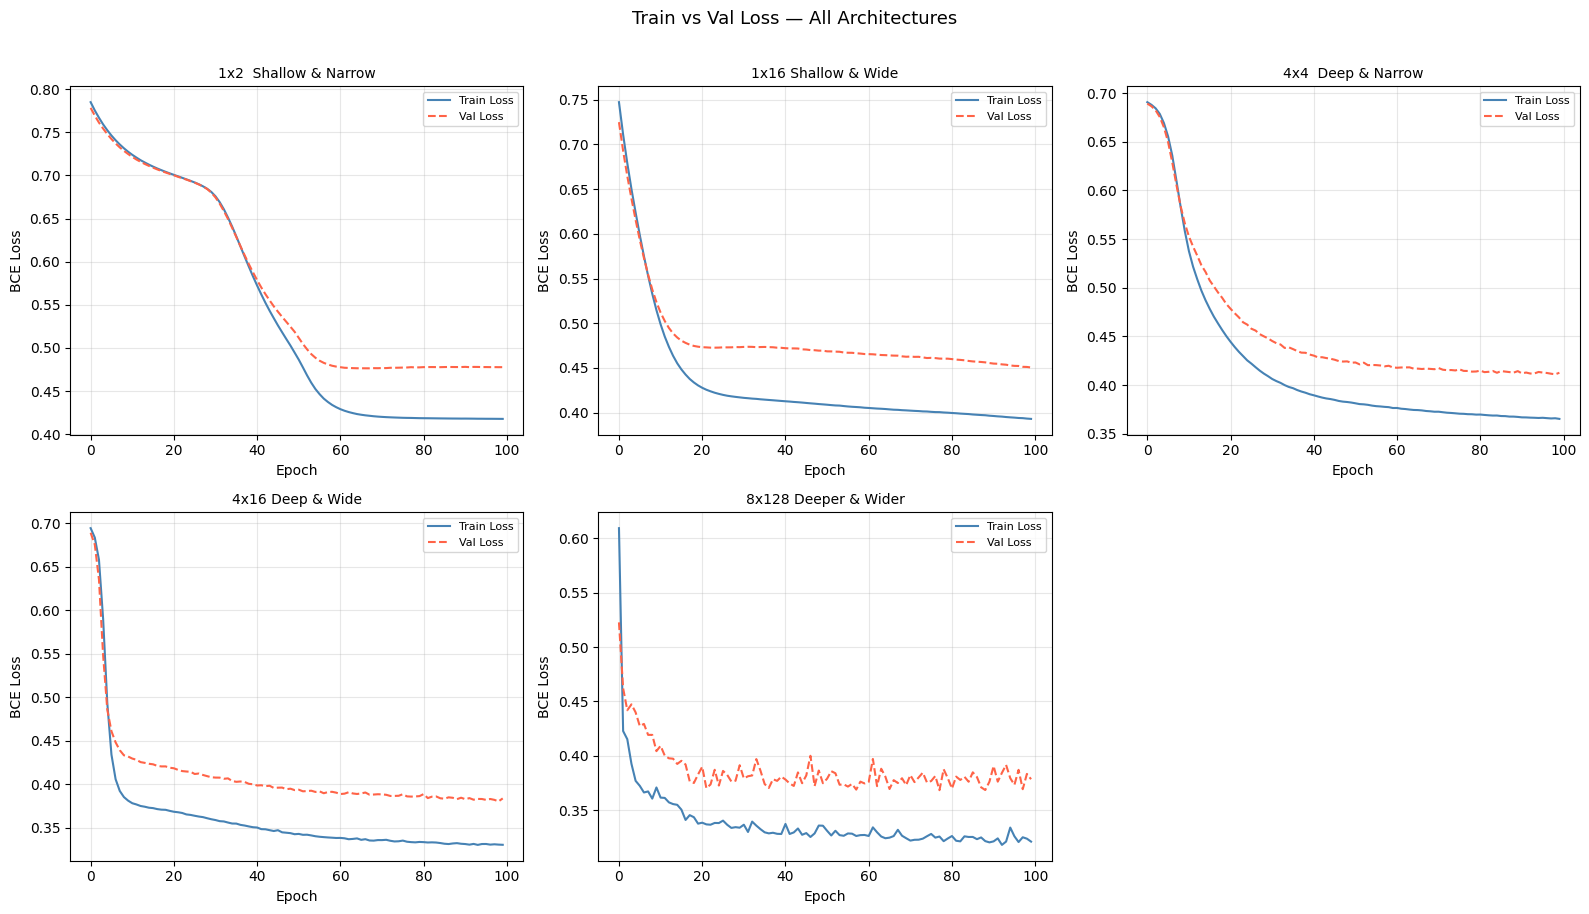

In [8]:
# ── Loss curves for all models ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for idx, (name, res) in enumerate(results.items()):
    ax = axes[idx]
    ax.plot(res['train_losses'], label='Train Loss', color='steelblue')
    ax.plot(res['val_losses'],   label='Val Loss',   color='tomato', linestyle='--')
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('BCE Loss')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

# Hide the 6th empty subplot
axes[-1].set_visible(False)

plt.suptitle('Train vs Val Loss — All Architectures', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

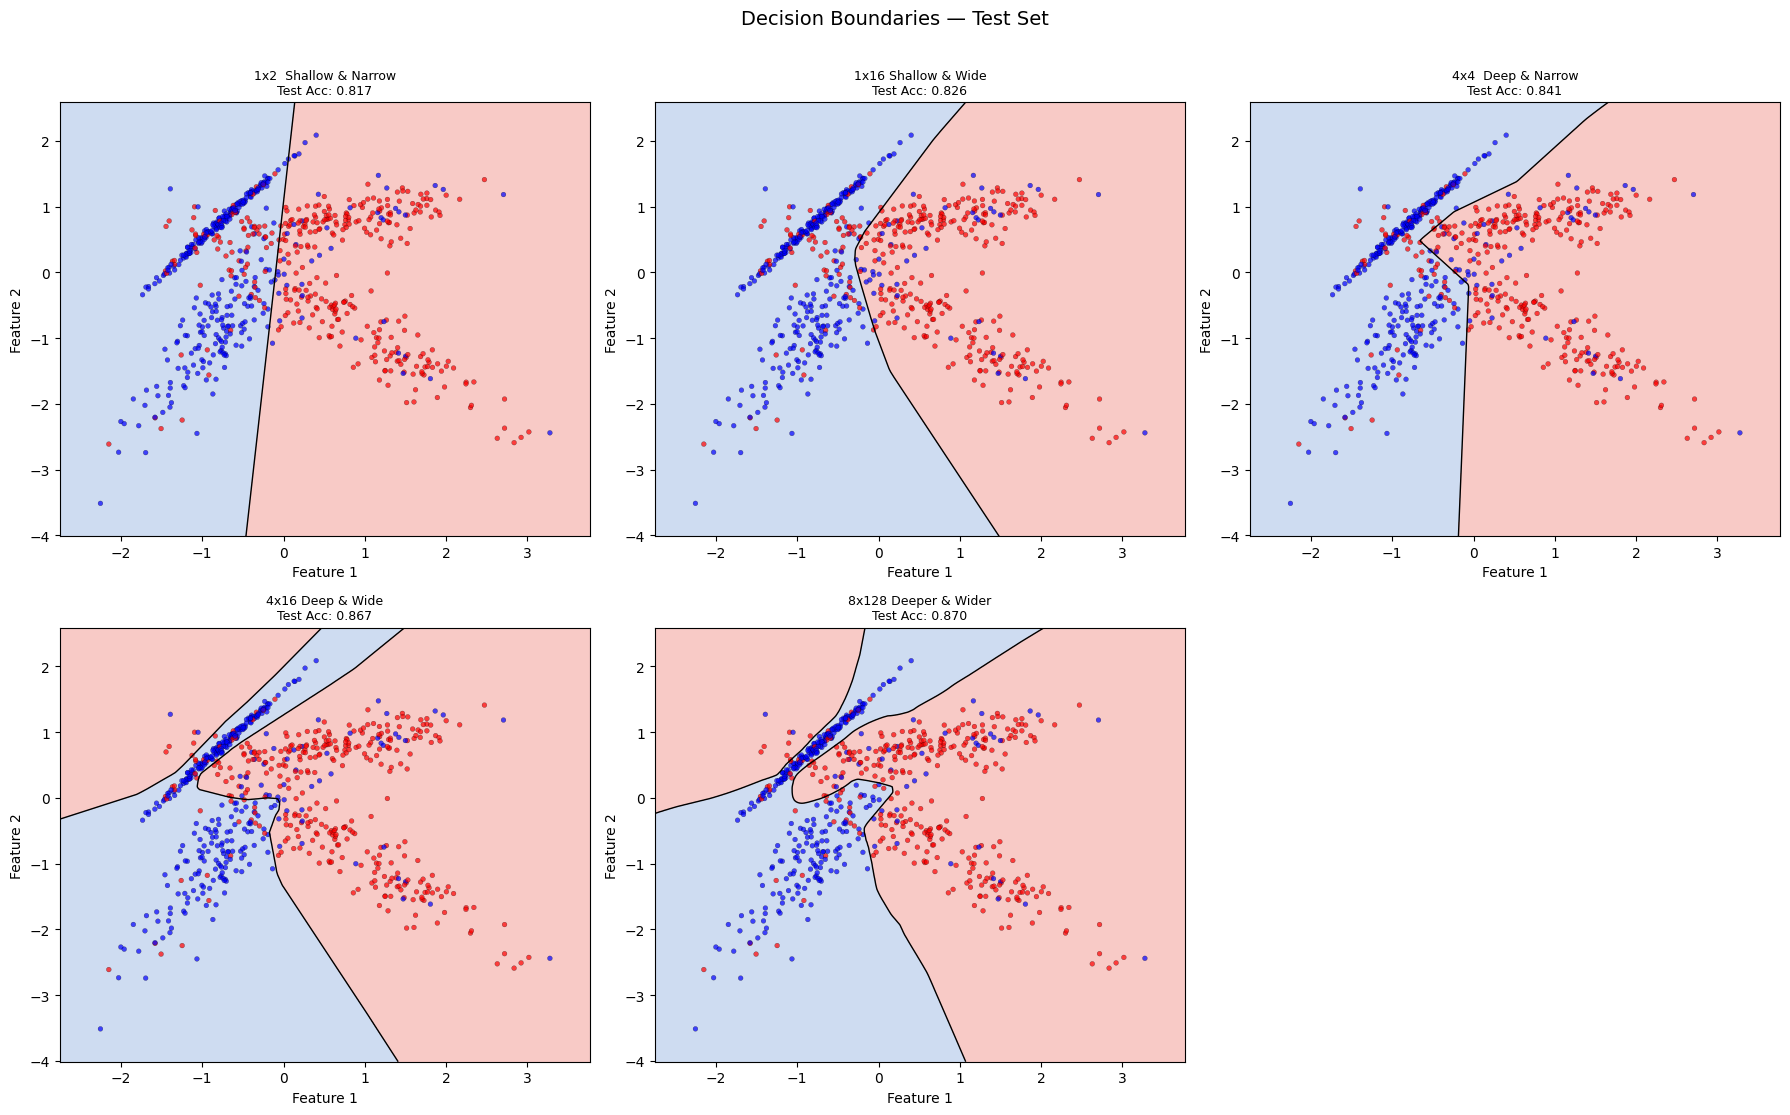

In [9]:
# ── Decision boundary helper ───────────────────────────────────────────────────
def plot_decision_boundary(model, X, y, title='', ax=None):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

    model.eval()
    with torch.no_grad():
        Z = model(grid).view(-1).numpy()
    Z = Z.reshape(xx.shape)

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))

    ax.contourf(xx, yy, Z, levels=[0, 0.5, 1], colors=['#AEC6E8', '#F4A7A0'], alpha=0.6)
    ax.contour(xx,  yy, Z, levels=[0.5], colors='black', linewidths=1)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k',
               linewidths=0.2, s=12, alpha=0.7)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')


# Plot for test set
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for idx, (name, res) in enumerate(results.items()):
    plot_decision_boundary(
        res['model'], X_test, y_test,
        title=f"{name}\nTest Acc: {res['test_acc']:.3f}",
        ax=axes[idx]
    )

axes[-1].set_visible(False)
plt.suptitle('Decision Boundaries — Test Set', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [10]:
# ── Summary table ──────────────────────────────────────────────────────────────
print(f'{"Model":<28} {"Train Loss":>12} {"Val Loss":>10} {"Test Acc":>10}')
print('-' * 64)
for name, res in results.items():
    print(f'{name:<28} {res["train_losses"][-1]:>12.4f} {res["val_losses"][-1]:>10.4f} {res["test_acc"]:>10.4f}')

Model                          Train Loss   Val Loss   Test Acc
----------------------------------------------------------------
1x2  Shallow & Narrow              0.4178     0.4777     0.8171
1x16 Shallow & Wide                0.3931     0.4506     0.8257
4x4  Deep & Narrow                 0.3653     0.4127     0.8414
4x16 Deep & Wide                   0.3301     0.3835     0.8671
8x128 Deeper & Wider               0.3213     0.3786     0.8700


---
## Section 3 — Bias & Variance Estimation (Bootstrap)

In [11]:
def train_model_no_val(model, train_loader, epochs=50, lr=0.001):
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    for epoch in range(epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch).view(-1)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
    return model


def bootstrap_bias_variance(
    create_model,
    X_train, y_train,
    X_test,  y_test,
    n_bootstrap=30,
    epochs=50,
    batch_size=128,
    lr=0.001
):
    y_test = np.array(y_test).reshape(-1)
    n_test = len(X_test)
    predictions = np.zeros((n_bootstrap, n_test))
    bootstrap_losses = []

    for b in tqdm(range(n_bootstrap), desc='Bootstrap iterations'):
        X_boot, y_boot = resample(
            X_train, y_train,
            replace=True,
            n_samples=len(X_train),
            stratify=y_train,
            random_state=42 + b
        )
        X_tensor = torch.tensor(X_boot, dtype=torch.float32)
        y_tensor = torch.tensor(y_boot, dtype=torch.float32)
        dataset  = TensorDataset(X_tensor, y_tensor)
        loader   = DataLoader(dataset, batch_size=batch_size, shuffle=True)

        model = create_model()
        model = train_model_no_val(model=model, train_loader=loader, epochs=epochs, lr=lr)

        model.eval()
        with torch.no_grad():
            test_tensor = torch.tensor(X_test, dtype=torch.float32)
            preds = model(test_tensor).numpy().reshape(-1)

        predictions[b] = preds
        bootstrap_losses.append(np.mean((preds - y_test) ** 2))

    mean_pred = predictions.mean(axis=0)
    bias2    = np.mean((mean_pred - y_test) ** 2)
    variance = np.mean(np.var(predictions, axis=0))
    error    = np.mean(bootstrap_losses)

    return error, bias2, variance, bootstrap_losses


print('Bootstrap functions defined.')

Bootstrap functions defined.


In [12]:
torch.manual_seed(42)
np.random.seed(42)

# Model 1x2
def create_model_1x2():
    return build_mlp([2, 2, 1])

# Model 4x4
def create_model_4x4():
    return build_mlp([2, 4, 4, 4, 4, 1])


print('Running bootstrap for 1x2 ...')
error_1x2, bias2_1x2, variance_1x2, losses_1x2 = bootstrap_bias_variance(
    create_model=create_model_1x2,
    X_train=X_train, y_train=y_train,
    X_test=X_test,   y_test=y_test,
    n_bootstrap=30, epochs=50, batch_size=128, lr=0.001
)

print('\nRunning bootstrap for 4x4 ...')
error_4x4, bias2_4x4, variance_4x4, losses_4x4 = bootstrap_bias_variance(
    create_model=create_model_4x4,
    X_train=X_train, y_train=y_train,
    X_test=X_test,   y_test=y_test,
    n_bootstrap=30, epochs=50, batch_size=128, lr=0.001
)

print('\nBootstrap complete.')

Running bootstrap for 1x2 ...


Bootstrap iterations: 100%|█████████████████████████████████| 30/30 [01:49<00:00,  3.66s/it]



Running bootstrap for 4x4 ...


Bootstrap iterations: 100%|█████████████████████████████████| 30/30 [01:39<00:00,  3.31s/it]


Bootstrap complete.


C:\Users\Reza\AppData\Local\Temp\ipykernel_14656\2101776479.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(data, labels=model_names, patch_artist=True)


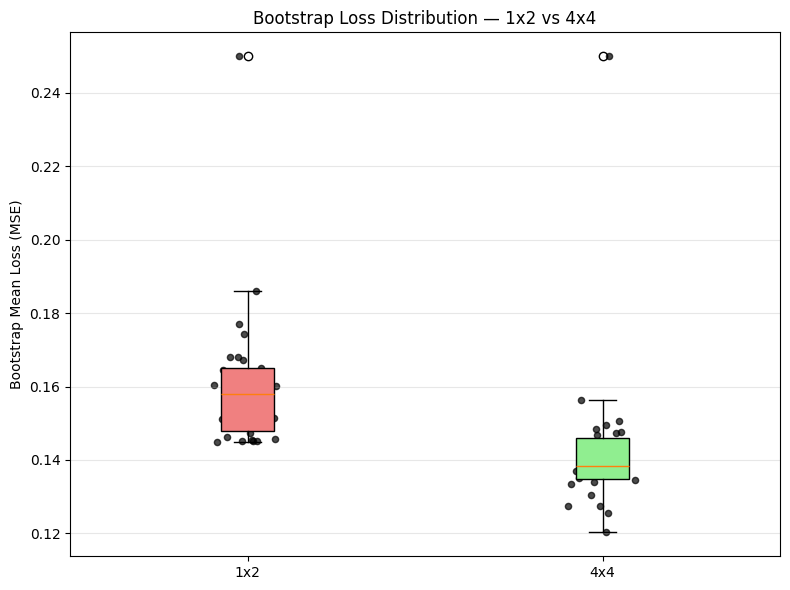


Bias-Variance Decomposition Results:
1x2:
  Error    = 0.1604
  Bias²    = 0.1503
  Variance = 0.0101

4x4:
  Error    = 0.1425
  Bias²    = 0.1326
  Variance = 0.0099



In [13]:
bootstrap_results = {
    '1x2': {'error': error_1x2, 'bias2': bias2_1x2, 'variance': variance_1x2},
    '4x4': {'error': error_4x4, 'bias2': bias2_4x4, 'variance': variance_4x4},
}

loss_results = {
    '1x2': losses_1x2,
    '4x4': losses_4x4,
}

# Boxplot
plt.figure(figsize=(8, 6))
model_names = list(loss_results.keys())
data = [loss_results[n] for n in model_names]

bp = plt.boxplot(data, labels=model_names, patch_artist=True)
colors = ['lightcoral', 'lightgreen']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

for i, losses in enumerate(data):
    x = np.random.normal(i + 1, 0.05, size=len(losses))
    plt.scatter(x, losses, color='black', alpha=0.7, s=20)

plt.ylabel('Bootstrap Mean Loss (MSE)')
plt.title('Bootstrap Loss Distribution — 1x2 vs 4x4')
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Print decomposition
print('\n' + '=' * 50)
print('Bias-Variance Decomposition Results:')
print('=' * 50)
for name in model_names:
    print(f'{name}:')
    print(f'  Error    = {bootstrap_results[name]["error"]:.4f}')
    print(f'  Bias²    = {bootstrap_results[name]["bias2"]:.4f}')
    print(f'  Variance = {bootstrap_results[name]["variance"]:.4f}')
    print()

---
## Section 4 — Activation Function Experiment

In [14]:
# Deep network: 8 hidden layers x 64 neurons
HIDDEN_SIZES_DEEP = [2] + [64] * 8 + [1]

def build_mlp_custom_act(layer_sizes, activation_cls, init='default'):
    """Build MLP with a custom activation. Optional Xavier init for Sigmoid."""
    layers = []
    for i in range(len(layer_sizes) - 1):
        linear = nn.Linear(layer_sizes[i], layer_sizes[i + 1])
        if init == 'xavier':
            nn.init.xavier_uniform_(linear.weight)
            nn.init.zeros_(linear.bias)
        layers.append(linear)
        if i < len(layer_sizes) - 2:
            layers.append(activation_cls())
    layers.append(nn.Sigmoid())
    return nn.Sequential(*layers)


activation_configs = {
    'ReLU':      (nn.ReLU,       'default'),
    'Sigmoid':   (nn.Sigmoid,    'xavier'),   # Xavier init to mitigate vanishing gradient
    'LeakyReLU': (nn.LeakyReLU,  'default'),
    'Tanh':      (nn.Tanh,       'default'),  # Bonus
}

torch.manual_seed(42)
act_results = {}

for act_name, (act_cls, init) in activation_configs.items():
    print(f'Training with {act_name} ...')
    model = build_mlp_custom_act(HIDDEN_SIZES_DEEP, act_cls, init=init)
    model, tr_l, va_l = train_model(model, train_loader, test_loader, epochs=EPOCHS, lr=LR)
    acc = evaluate(model, X_test_t, y_test)
    act_results[act_name] = {'model': model, 'train_losses': tr_l, 'val_losses': va_l, 'test_acc': acc}
    print(f'  Final val loss: {va_l[-1]:.4f} | test acc: {acc:.4f}')

print('\nActivation experiments done.')

Training with ReLU ...
  Final val loss: 0.3869 | test acc: 0.8643
Training with Sigmoid ...
  Final val loss: 0.4556 | test acc: 0.8143
Training with LeakyReLU ...
  Final val loss: 0.3714 | test acc: 0.8757
Training with Tanh ...
  Final val loss: 0.3720 | test acc: 0.8643

Activation experiments done.


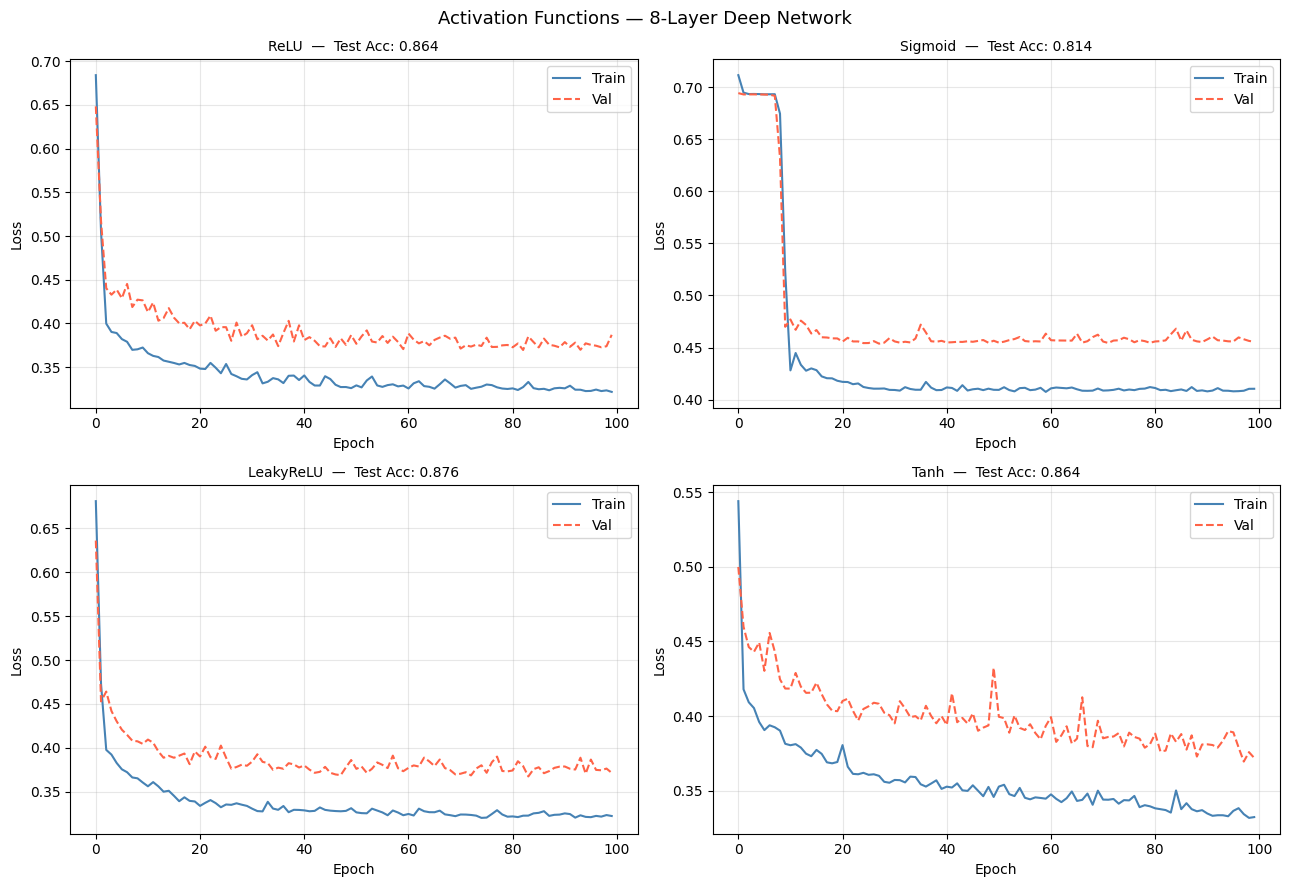

Activation       Val Loss   Test Acc
--------------------------------------
ReLU               0.3869     0.8643
Sigmoid            0.4556     0.8143
LeakyReLU          0.3714     0.8757
Tanh               0.3720     0.8643


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for idx, (act_name, res) in enumerate(act_results.items()):
    ax = axes[idx]
    ax.plot(res['train_losses'], label='Train', color='steelblue')
    ax.plot(res['val_losses'],   label='Val',   color='tomato', linestyle='--')
    ax.set_title(f'{act_name}  —  Test Acc: {res["test_acc"]:.3f}', fontsize=10)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Activation Functions — 8-Layer Deep Network', fontsize=13)
plt.tight_layout()
plt.show()

print(f'{"Activation":<14} {"Val Loss":>10} {"Test Acc":>10}')
print('-' * 38)
for act_name, res in act_results.items():
    print(f'{act_name:<14} {res["val_losses"][-1]:>10.4f} {res["test_acc"]:>10.4f}')

---
## Section 5 — Regularization Experiment (Dropout vs L2)

In [16]:
# Architecture: 8x128
HIDDEN_8x128 = [2] + [128] * 8 + [1]


def build_mlp_dropout(layer_sizes, dropout_rate=0.3):
    """MLP with Dropout after each hidden layer."""
    layers = []
    for i in range(len(layer_sizes) - 1):
        layers.append(nn.Linear(layer_sizes[i], layer_sizes[i + 1]))
        if i < len(layer_sizes) - 2:
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(p=dropout_rate))
    layers.append(nn.Sigmoid())
    return nn.Sequential(*layers)


def train_model_l2(model, train_loader, test_loader, epochs=EPOCHS, lr=LR, weight_decay=1e-4):
    """Train with L2 regularization (via Adam's weight_decay)."""
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    train_losses, val_losses = [], []
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for Xb, yb in train_loader:
            optimizer.zero_grad()
            pred = model(Xb).view(-1)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * Xb.size(0)
        train_losses.append(running_loss / len(train_loader.dataset))
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for Xb, yb in test_loader:
                pred = model(Xb).view(-1)
                val_loss += criterion(pred, yb).item() * Xb.size(0)
        val_losses.append(val_loss / len(test_loader.dataset))
    return model, train_losses, val_losses


torch.manual_seed(42)

# (a) No regularization
print('Training: No Regularization ...')
model_noreg = build_mlp(HIDDEN_8x128)
model_noreg, tr_noreg, va_noreg = train_model(model_noreg, train_loader, test_loader)
acc_noreg = evaluate(model_noreg, X_test_t, y_test)

# (b) Dropout
print('Training: Dropout (p=0.3) ...')
model_drop = build_mlp_dropout(HIDDEN_8x128, dropout_rate=0.3)
model_drop, tr_drop, va_drop = train_model(model_drop, train_loader, test_loader)
acc_drop = evaluate(model_drop, X_test_t, y_test)

# (c) L2
print('Training: L2 (weight_decay=1e-4) ...')
model_l2 = build_mlp(HIDDEN_8x128)
model_l2, tr_l2, va_l2 = train_model_l2(model_l2, train_loader, test_loader, weight_decay=1e-4)
acc_l2 = evaluate(model_l2, X_test_t, y_test)

print(f'\nNo Reg   — val loss: {va_noreg[-1]:.4f}, test acc: {acc_noreg:.4f}')
print(f'Dropout  — val loss: {va_drop[-1]:.4f},  test acc: {acc_drop:.4f}')
print(f'L2 Reg   — val loss: {va_l2[-1]:.4f},   test acc: {acc_l2:.4f}')

Training: No Regularization ...
Training: Dropout (p=0.3) ...
Training: L2 (weight_decay=1e-4) ...

No Reg   — val loss: 0.3697, test acc: 0.8729
Dropout  — val loss: 0.3679,  test acc: 0.8714
L2 Reg   — val loss: 0.3731,   test acc: 0.8729


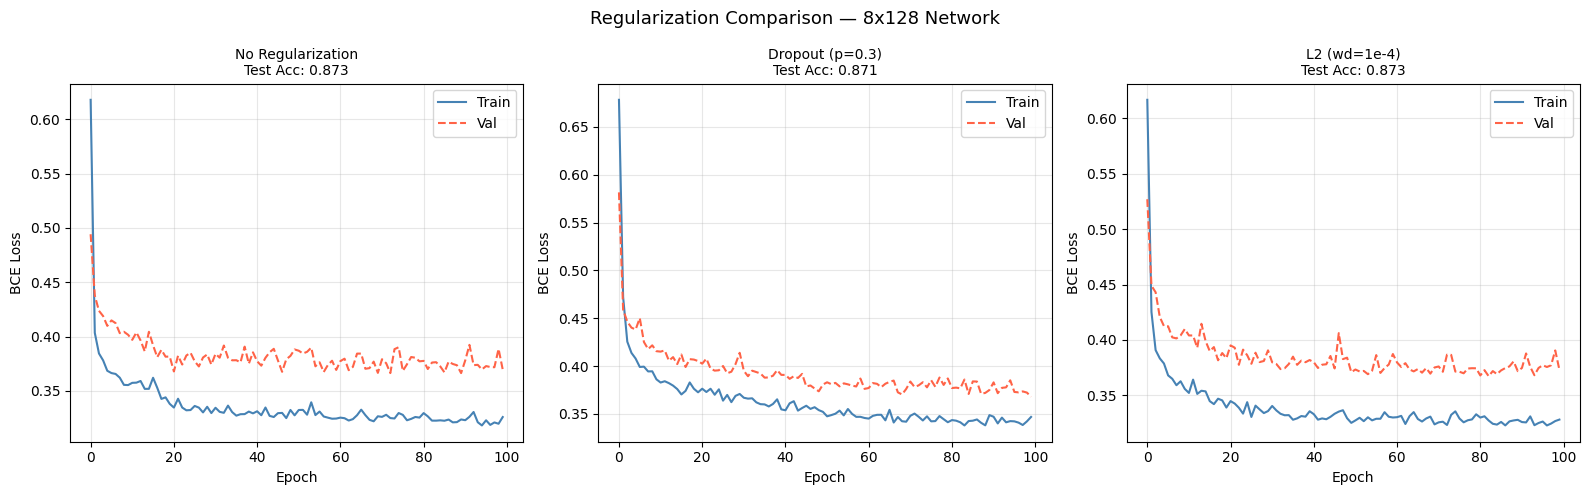

In [17]:
reg_configs = {
    'No Regularization': (tr_noreg, va_noreg, acc_noreg),
    'Dropout (p=0.3)':   (tr_drop,  va_drop,  acc_drop),
    'L2 (wd=1e-4)':      (tr_l2,    va_l2,    acc_l2),
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (label, (tr, va, acc)) in zip(axes, reg_configs.items()):
    ax.plot(tr, label='Train', color='steelblue')
    ax.plot(va, label='Val',   color='tomato', linestyle='--')
    ax.set_title(f'{label}\nTest Acc: {acc:.3f}', fontsize=10)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('BCE Loss')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Regularization Comparison — 8x128 Network', fontsize=13)
plt.tight_layout()
plt.show()

---
## Section 6 — Learning Rate, Optimizer & Batch Size Experiments

LR=0.001: val_loss=0.6931, acc=0.5043
LR=0.01: val_loss=0.6929, acc=0.5043
LR=0.1: val_loss=0.3964, acc=0.8557
LR=0.5: val_loss=0.3742, acc=0.8629


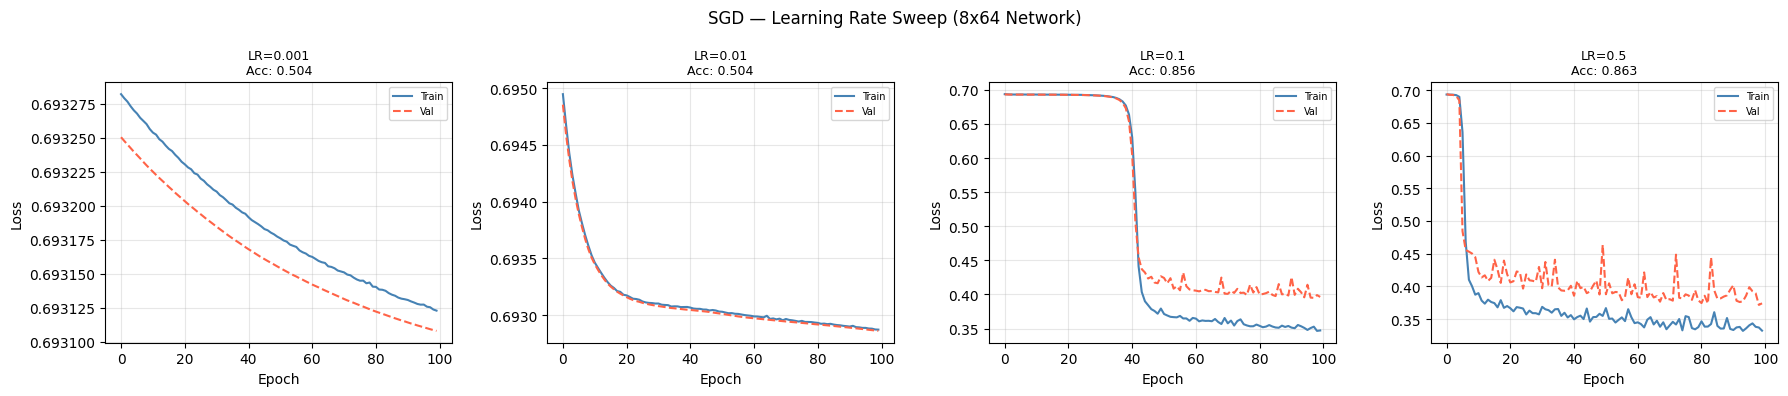

In [18]:
# Architecture: 8x64
HIDDEN_8x64 = [2] + [64] * 8 + [1]


def train_sgd(model, train_loader, test_loader, epochs=EPOCHS, lr=0.01):
    criterion = nn.BCELoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)
    train_losses, val_losses = [], []
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for Xb, yb in train_loader:
            optimizer.zero_grad()
            pred = model(Xb).view(-1)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * Xb.size(0)
        train_losses.append(running_loss / len(train_loader.dataset))
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for Xb, yb in test_loader:
                pred = model(Xb).view(-1)
                val_loss += criterion(pred, yb).item() * Xb.size(0)
        val_losses.append(val_loss / len(test_loader.dataset))
    return model, train_losses, val_losses


# ── 6a: Learning rate sweep with SGD ──────────────────────────────────────────
lr_values = [0.001, 0.01, 0.1, 0.5]
lr_results = {}

torch.manual_seed(42)
for lr_val in lr_values:
    model = build_mlp(HIDDEN_8x64)
    model, tr_l, va_l = train_sgd(model, train_loader, test_loader, epochs=EPOCHS, lr=lr_val)
    acc = evaluate(model, X_test_t, y_test)
    lr_results[lr_val] = {'train_losses': tr_l, 'val_losses': va_l, 'test_acc': acc}
    print(f'LR={lr_val}: val_loss={va_l[-1]:.4f}, acc={acc:.4f}')

# Plot
fig, axes = plt.subplots(1, len(lr_values), figsize=(18, 4))
for ax, (lr_val, res) in zip(axes, lr_results.items()):
    ax.plot(res['train_losses'], label='Train', color='steelblue')
    ax.plot(res['val_losses'],   label='Val',   color='tomato', linestyle='--')
    ax.set_title(f'LR={lr_val}\nAcc: {res["test_acc"]:.3f}', fontsize=9)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.suptitle('SGD — Learning Rate Sweep (8x64 Network)', fontsize=12)
plt.tight_layout()
plt.show()

BatchSize=32: val_loss=0.6433, acc=0.8200
BatchSize=128: val_loss=0.6929, acc=0.5043
BatchSize=256: val_loss=0.6930, acc=0.5043


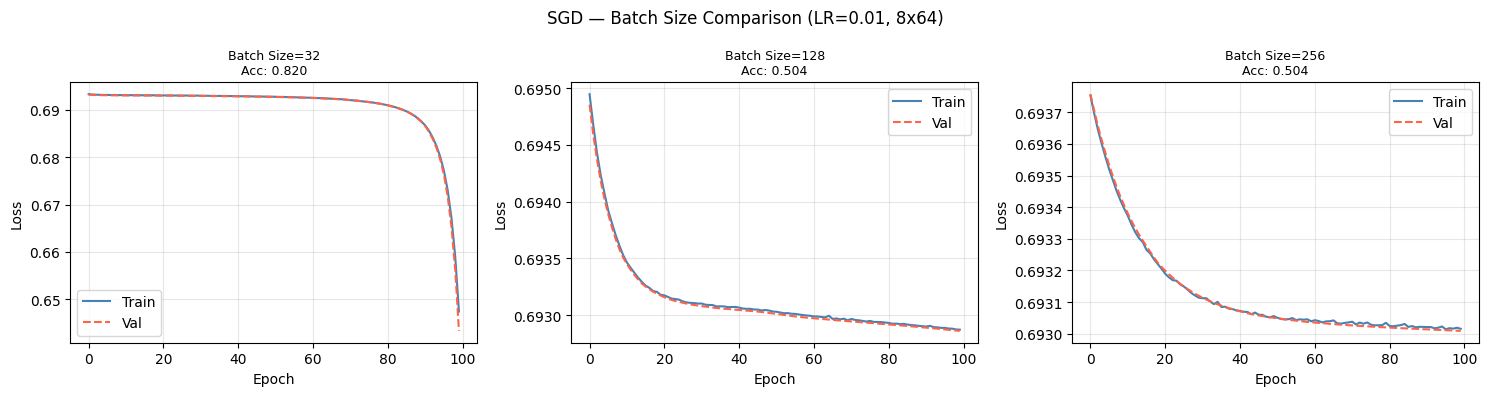

In [19]:
# ── 6b: Batch size sweep with SGD (best LR=0.01) ──────────────────────────────
batch_sizes = [32, 128, 256]
batch_results = {}

torch.manual_seed(42)
for bs in batch_sizes:
    tr_ds = TensorDataset(X_train_t, y_train_t)
    tr_ld = DataLoader(tr_ds, batch_size=bs, shuffle=True)

    model = build_mlp(HIDDEN_8x64)
    model, tr_l, va_l = train_sgd(model, tr_ld, test_loader, epochs=EPOCHS, lr=0.01)
    acc = evaluate(model, X_test_t, y_test)
    batch_results[bs] = {'train_losses': tr_l, 'val_losses': va_l, 'test_acc': acc}
    print(f'BatchSize={bs}: val_loss={va_l[-1]:.4f}, acc={acc:.4f}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (bs, res) in zip(axes, batch_results.items()):
    ax.plot(res['train_losses'], label='Train', color='steelblue')
    ax.plot(res['val_losses'],   label='Val',   color='tomato', linestyle='--')
    ax.set_title(f'Batch Size={bs}\nAcc: {res["test_acc"]:.3f}', fontsize=9)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('SGD — Batch Size Comparison (LR=0.01, 8x64)', fontsize=12)
plt.tight_layout()
plt.show()

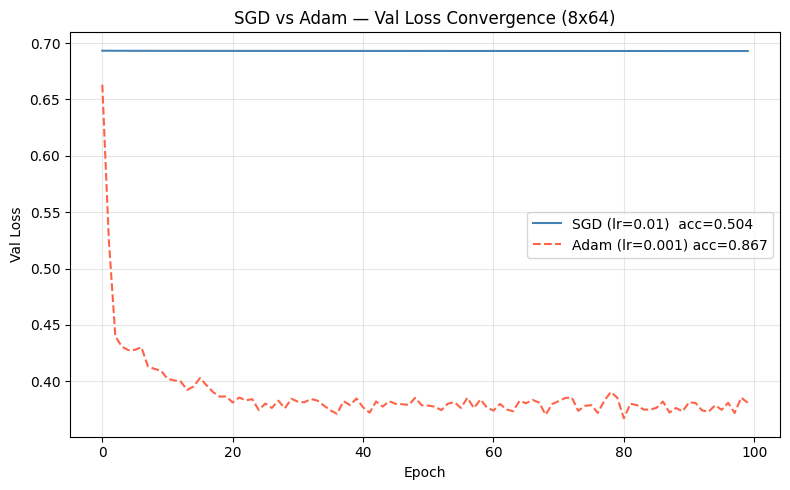

In [20]:
# ── 6c (Bonus): Adam vs SGD ────────────────────────────────────────────────────
torch.manual_seed(42)

model_sgd  = build_mlp(HIDDEN_8x64)
model_adam = build_mlp(HIDDEN_8x64)

model_sgd,  tr_sgd,  va_sgd  = train_sgd(  model_sgd,  train_loader, test_loader, lr=0.01)
model_adam, tr_adam, va_adam = train_model(model_adam, train_loader, test_loader, lr=0.001)

acc_sgd  = evaluate(model_sgd,  X_test_t, y_test)
acc_adam = evaluate(model_adam, X_test_t, y_test)

plt.figure(figsize=(8, 5))
plt.plot(va_sgd,  label=f'SGD (lr=0.01)  acc={acc_sgd:.3f}',  color='steelblue')
plt.plot(va_adam, label=f'Adam (lr=0.001) acc={acc_adam:.3f}', color='tomato', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Val Loss')
plt.title('SGD vs Adam — Val Loss Convergence (8x64)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
# Part II — Real Dataset: CovType

In [21]:
df = pd.read_csv('covtype.csv')
print(f'Dataset shape: {df.shape}')
print(df.head())

X_cov = df.iloc[:, :-1].values
y_cov = df.iloc[:, -1].values - 1   # Convert 1..7 to 0..6

print(f'\nFeatures: {X_cov.shape[1]}, Classes: {len(np.unique(y_cov))}')
print(f'Label range: {y_cov.min()} to {y_cov.max()}')

Dataset shape: (581012, 55)
   Elevation  Aspect  Slope  Horizontal_Distance_To_Hydrology  \
0     2596.0    51.0    3.0                             258.0   
1     2590.0    56.0    2.0                             212.0   
2     2804.0   139.0    9.0                             268.0   
3     2785.0   155.0   18.0                             242.0   
4     2595.0    45.0    2.0                             153.0   

   Vertical_Distance_To_Hydrology  Horizontal_Distance_To_Roadways  \
0                             0.0                            510.0   
1                            -6.0                            390.0   
2                            65.0                           3180.0   
3                           118.0                           3090.0   
4                            -1.0                            391.0   

   Hillshade_9am  Hillshade_Noon  Hillshade_3pm  \
0          221.0           232.0          148.0   
1          220.0           235.0          151.0   
2      

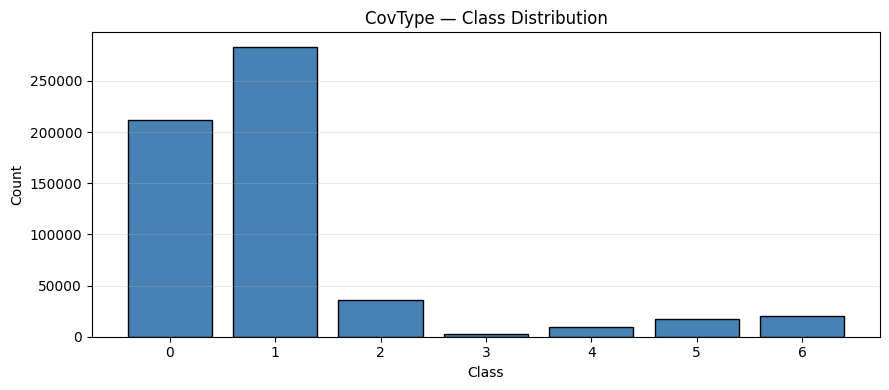

Class counts:
  Class 0: 211840  (36.5%)
  Class 1: 283301  (48.8%)
  Class 2:  35754  (6.2%)
  Class 3:   2747  (0.5%)
  Class 4:   9493  (1.6%)
  Class 5:  17367  (3.0%)
  Class 6:  20510  (3.5%)

Dataset is imbalanced — using Macro F1 as evaluation metric.


In [22]:
# Class distribution
unique, counts = np.unique(y_cov, return_counts=True)

plt.figure(figsize=(9, 4))
plt.bar(unique, counts, color='steelblue', edgecolor='k')
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('CovType — Class Distribution')
plt.xticks(unique)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('Class counts:')
for cls, cnt in zip(unique, counts):
    print(f'  Class {cls}: {cnt:>6d}  ({100*cnt/len(y_cov):.1f}%)')

print('\nDataset is imbalanced — using Macro F1 as evaluation metric.')

In [23]:
# Train/val/test split: 70/15/15
X_tr_cov, X_tmp, y_tr_cov, y_tmp = train_test_split(
    X_cov, y_cov, test_size=0.30, random_state=42, stratify=y_cov
)
X_va_cov, X_te_cov, y_va_cov, y_te_cov = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=42, stratify=y_tmp
)

# StandardScaler — fit only on train
scaler_cov = StandardScaler()
X_tr_cov = scaler_cov.fit_transform(X_tr_cov)
X_va_cov = scaler_cov.transform(X_va_cov)
X_te_cov = scaler_cov.transform(X_te_cov)

# Tensors
X_tr_t = torch.tensor(X_tr_cov, dtype=torch.float32)
y_tr_t = torch.tensor(y_tr_cov, dtype=torch.long)
X_va_t = torch.tensor(X_va_cov, dtype=torch.float32)
y_va_t = torch.tensor(y_va_cov, dtype=torch.long)
X_te_t = torch.tensor(X_te_cov, dtype=torch.float32)

BS_COV = 256
tr_ld_cov = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=BS_COV, shuffle=True)
va_ld_cov = DataLoader(TensorDataset(X_va_t, y_va_t), batch_size=BS_COV, shuffle=False)

N_FEATURES = X_tr_cov.shape[1]
N_CLASSES  = 7

print(f'Train: {len(X_tr_cov)}, Val: {len(X_va_cov)}, Test: {len(X_te_cov)}')

Train: 406708, Val: 87152, Test: 87152


In [24]:
# ── Multiclass MLP builder ─────────────────────────────────────────────────────
def build_multiclass_mlp(input_dim, hidden_sizes, n_classes, dropout_rate=0.0):
    """MLP for multiclass with optional Dropout."""
    all_sizes = [input_dim] + hidden_sizes + [n_classes]
    layers = []
    for i in range(len(all_sizes) - 1):
        layers.append(nn.Linear(all_sizes[i], all_sizes[i + 1]))
        if i < len(all_sizes) - 2:
            layers.append(nn.ReLU())
            if dropout_rate > 0:
                layers.append(nn.Dropout(p=dropout_rate))
    return nn.Sequential(*layers)   # raw logits — CrossEntropyLoss handles softmax


def train_multiclass(model, tr_loader, va_loader, epochs=50, lr=0.001, weight_decay=0.0):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        running = 0.0
        for Xb, yb in tr_loader:
            optimizer.zero_grad()
            logits = model(Xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            running += loss.item() * Xb.size(0)
        train_losses.append(running / len(tr_loader.dataset))

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for Xb, yb in va_loader:
                logits = model(Xb)
                val_loss += criterion(logits, yb).item() * Xb.size(0)
        val_losses.append(val_loss / len(va_loader.dataset))

        if (epoch + 1) % 10 == 0:
            print(f'  Epoch {epoch+1:>3}/{epochs}  train={train_losses[-1]:.4f}  val={val_losses[-1]:.4f}')

    return model, train_losses, val_losses


def evaluate_multiclass(model, X_tensor, y_true):
    model.eval()
    with torch.no_grad():
        logits = model(X_tensor)
        preds  = logits.argmax(dim=1).numpy()
    acc = accuracy_score(y_true, preds)
    f1  = f1_score(y_true, preds, average='macro', zero_division=0)
    return acc, f1


print('Multiclass helpers ready.')

Multiclass helpers ready.


In [25]:
torch.manual_seed(42)
EPOCHS_COV = 50

# ── Model A: Simple (2 hidden layers, 128 neurons) ─────────────────────────────
print('=== Model A: Simple [128, 128] ===')
model_A = build_multiclass_mlp(N_FEATURES, [128, 128], N_CLASSES)
model_A, tr_A, va_A = train_multiclass(model_A, tr_ld_cov, va_ld_cov, epochs=EPOCHS_COV, lr=0.001)
acc_A, f1_A = evaluate_multiclass(model_A, X_te_t, y_te_cov)
print(f'Test Acc: {acc_A:.4f}, Macro F1: {f1_A:.4f}\n')

# ── Model B: Complex (4 hidden layers, 512 neurons, dropout) ───────────────────
print('=== Model B: Complex [512, 512, 256, 128] + Dropout ===')
model_B = build_multiclass_mlp(N_FEATURES, [512, 512, 256, 128], N_CLASSES, dropout_rate=0.3)
model_B, tr_B, va_B = train_multiclass(
    model_B, tr_ld_cov, va_ld_cov, epochs=EPOCHS_COV, lr=0.001, weight_decay=1e-4
)
acc_B, f1_B = evaluate_multiclass(model_B, X_te_t, y_te_cov)
print(f'Test Acc: {acc_B:.4f}, Macro F1: {f1_B:.4f}')

=== Model A: Simple [128, 128] ===
  Epoch  10/50  train=0.3043  val=0.3062
  Epoch  20/50  train=0.2511  val=0.2771
  Epoch  30/50  train=0.2255  val=0.2392
  Epoch  40/50  train=0.2098  val=0.2191
  Epoch  50/50  train=0.1972  val=0.2174
Test Acc: 0.9151, Macro F1: 0.8782

=== Model B: Complex [512, 512, 256, 128] + Dropout ===
  Epoch  10/50  train=0.3453  val=0.2824
  Epoch  20/50  train=0.3143  val=0.2465
  Epoch  30/50  train=0.3017  val=0.2364
  Epoch  40/50  train=0.2946  val=0.2328
  Epoch  50/50  train=0.2891  val=0.2179
Test Acc: 0.9132, Macro F1: 0.8577


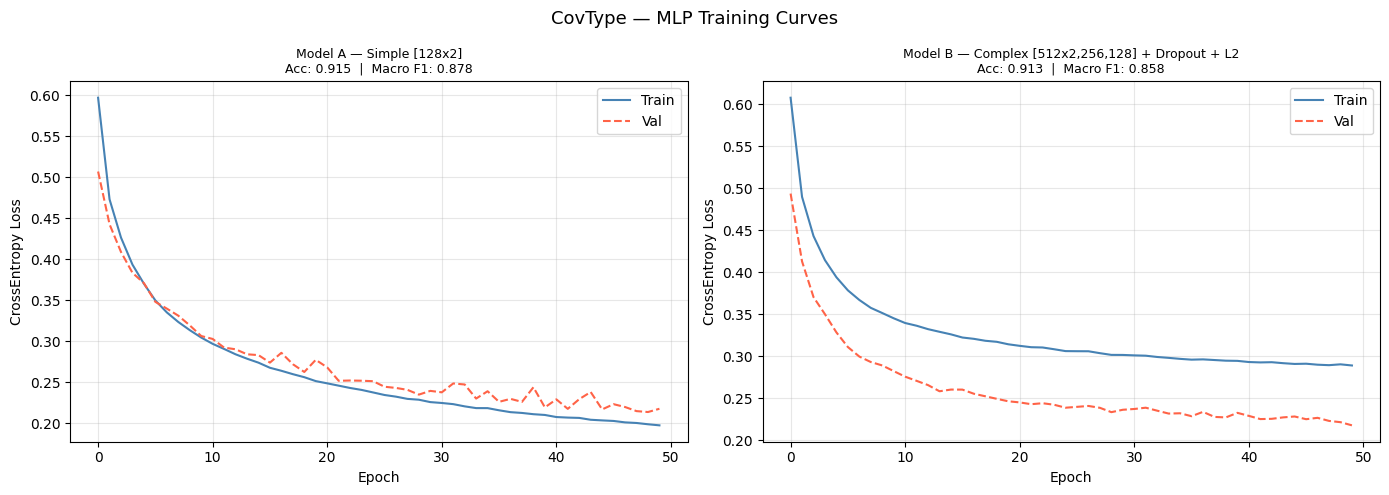


=== Final Results ===
Model A  — Accuracy: 0.9151, Macro F1: 0.8782
Model B  — Accuracy: 0.9132, Macro F1: 0.8577


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (label, tr, va, acc, f1) in zip(axes, [
    ('Model A — Simple [128x2]', tr_A, va_A, acc_A, f1_A),
    ('Model B — Complex [512x2,256,128] + Dropout + L2', tr_B, va_B, acc_B, f1_B),
]):
    ax.plot(tr, label='Train', color='steelblue')
    ax.plot(va, label='Val',   color='tomato', linestyle='--')
    ax.set_title(f'{label}\nAcc: {acc:.3f}  |  Macro F1: {f1:.3f}', fontsize=9)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('CrossEntropy Loss')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('CovType — MLP Training Curves', fontsize=13)
plt.tight_layout()
plt.show()

print('\n=== Final Results ===')
print(f'Model A  — Accuracy: {acc_A:.4f}, Macro F1: {f1_A:.4f}')
print(f'Model B  — Accuracy: {acc_B:.4f}, Macro F1: {f1_B:.4f}')